In [81]:
import pandas as pd


NOTEBOOK ĐỂ merge promo vào sales, tạo thêm các cột như doy, month, quarter, season, year để có thể phân tích theo thời gian. Đồng thời tách y thành 2 phần là revenue và cogs để có thể dự đoán riêng từng phần.

# LOAD VÀ LẢM NHẢM

In [82]:
sales = pd.read_csv('../../sales.csv')


In [83]:
sales


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [84]:
promotions = pd.read_csv('../../promotions.csv')


In [85]:
promotions.head(5)


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [86]:
promotions['start_date'] = pd.to_datetime(promotions['start_date'], format='%Y-%m-%d')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], format='%Y-%m-%d')


In [87]:
promotions.groupby(promotions['start_date'].dt.year).size().reset_index(name='count')


,start_date,count
0,2013,6
1,2014,4
2,2015,6
3,2016,4
4,2017,6
5,2018,4
6,2019,6
7,2020,4
8,2021,6
9,2022,4


In [88]:
spring_promos = promotions[promotions['promo_name'].str.contains('Spring', case=False, na=False)]
spring_promos


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,NaN,email,1,0
10,PROMO-0011,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,NaN,all_channels,1,100000
16,PROMO-0017,Spring Sale 2016,percentage,12.0,2016-03-18,2016-04-17,NaN,all_channels,0,0
20,PROMO-0021,Spring Sale 2017,percentage,12.0,2017-03-18,2017-04-17,NaN,all_channels,0,0
26,PROMO-0027,Spring Sale 2018,percentage,12.0,2018-03-18,2018-04-17,NaN,all_channels,0,100000
30,PROMO-0031,Spring Sale 2019,percentage,12.0,2019-03-18,2019-04-17,NaN,online,1,150000
36,PROMO-0037,Spring Sale 2020,percentage,12.0,2020-03-18,2020-04-17,NaN,online,0,0
40,PROMO-0041,Spring Sale 2021,percentage,12.0,2021-03-18,2021-04-17,NaN,online,1,0
46,PROMO-0047,Spring Sale 2022,percentage,12.0,2022-03-18,2022-04-17,NaN,all_channels,1,0


In [89]:
myear_promos = promotions[promotions['promo_name'].str.contains('Mid-Year', case=False, na=False)]
myear_promos


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,NaN,social_media,0,0
11,PROMO-0012,Mid-Year Sale 2015,percentage,18.0,2015-06-23,2015-07-22,NaN,social_media,0,0
17,PROMO-0018,Mid-Year Sale 2016,percentage,18.0,2016-06-23,2016-07-22,NaN,online,0,0
21,PROMO-0022,Mid-Year Sale 2017,percentage,18.0,2017-06-23,2017-07-22,NaN,online,0,150000
27,PROMO-0028,Mid-Year Sale 2018,percentage,18.0,2018-06-23,2018-07-22,NaN,social_media,0,150000
31,PROMO-0032,Mid-Year Sale 2019,percentage,18.0,2019-06-23,2019-07-22,NaN,social_media,0,0
37,PROMO-0038,Mid-Year Sale 2020,percentage,18.0,2020-06-23,2020-07-22,NaN,social_media,0,0
41,PROMO-0042,Mid-Year Sale 2021,percentage,18.0,2021-06-23,2021-07-22,NaN,social_media,1,0
47,PROMO-0048,Mid-Year Sale 2022,percentage,18.0,2022-06-23,2022-07-22,NaN,online,0,0


In [90]:
eyear_promos = promotions[promotions['promo_name'].str.contains('Year-End', case=False, na=False)]
eyear_promos


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,NaN,all_channels,0,100000
13,PROMO-0014,Year-End Sale 2015,percentage,20.0,2015-11-18,2016-01-02,NaN,all_channels,1,150000
19,PROMO-0020,Year-End Sale 2016,percentage,20.0,2016-11-18,2017-01-02,NaN,all_channels,0,0
23,PROMO-0024,Year-End Sale 2017,percentage,20.0,2017-11-18,2018-01-02,NaN,all_channels,0,0
29,PROMO-0030,Year-End Sale 2018,percentage,20.0,2018-11-18,2019-01-02,NaN,all_channels,0,0
33,PROMO-0034,Year-End Sale 2019,percentage,20.0,2019-11-18,2020-01-02,NaN,all_channels,0,50000
39,PROMO-0040,Year-End Sale 2020,percentage,20.0,2020-11-18,2021-01-01,NaN,all_channels,0,0
43,PROMO-0044,Year-End Sale 2021,percentage,20.0,2021-11-18,2022-01-02,NaN,all_channels,1,0
49,PROMO-0050,Year-End Sale 2022,percentage,20.0,2022-11-18,2022-12-31,NaN,all_channels,0,50000


In [91]:
fall_promos = promotions[promotions['promo_name'].str.contains('Fall', case=False, na=False)]
fall_promos


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,NaN,all_channels,0,100000
12,PROMO-0013,Fall Launch 2015,percentage,10.0,2015-08-30,2015-10-01,NaN,email,1,0
18,PROMO-0019,Fall Launch 2016,percentage,10.0,2016-08-30,2016-10-01,NaN,online,0,0
22,PROMO-0023,Fall Launch 2017,percentage,10.0,2017-08-30,2017-10-02,NaN,all_channels,1,0
28,PROMO-0029,Fall Launch 2018,percentage,10.0,2018-08-30,2018-10-01,NaN,email,0,0
32,PROMO-0033,Fall Launch 2019,percentage,10.0,2019-08-30,2019-10-01,NaN,email,0,50000
38,PROMO-0039,Fall Launch 2020,percentage,10.0,2020-08-30,2020-10-01,NaN,all_channels,0,150000
42,PROMO-0043,Fall Launch 2021,percentage,10.0,2021-08-30,2021-10-02,NaN,email,0,0
48,PROMO-0049,Fall Launch 2022,percentage,10.0,2022-08-31,2022-10-01,NaN,all_channels,0,0


In [92]:
urban_promos = promotions[promotions['promo_name'].str.contains('Urban', case=False, na=False)]
urban_promos


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
14,PROMO-0015,Urban Blowout 2015,fixed,50.0,2015-07-30,2015-09-02,Streetwear,online,0,200000
24,PROMO-0025,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0,150000
34,PROMO-0035,Urban Blowout 2019,fixed,50.0,2019-07-30,2019-09-02,Streetwear,online,0,100000
44,PROMO-0045,Urban Blowout 2021,fixed,50.0,2021-07-30,2021-09-02,Streetwear,online,0,200000


In [93]:
rural_promos = promotions[promotions['promo_name'].str.contains('Rural', case=False, na=False)]
rural_promos


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
15,PROMO-0016,Rural Special 2015,percentage,15.0,2015-01-30,2015-03-01,Outdoor,in_store,0,0
25,PROMO-0026,Rural Special 2017,percentage,15.0,2017-01-30,2017-03-01,Outdoor,in_store,0,0
35,PROMO-0036,Rural Special 2019,percentage,15.0,2019-01-30,2019-03-01,Outdoor,in_store,1,150000
45,PROMO-0046,Rural Special 2021,percentage,15.0,2021-01-30,2021-03-01,Outdoor,in_store,0,0


# Xử lý chính

In [94]:
sales.head(5)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [95]:
# dữ liệu sales
sales['Date'] = pd.to_datetime(sales['Date'])

# chuyển sang day of year
sales['doy'] = sales['Date'].dt.dayofyear

# define promo ranges (MM-DD)
promo_ranges = [
    ("03-18", "04-17"),
    ("06-23", "07-22"),
    ("11-18", "01-02"),  # qua năm
    ("08-30", "10-02")
]


In [96]:
def mmdd_to_doy(mmdd):
    return pd.to_datetime(f"2021-{mmdd}").dayofyear  # năm bất kỳ không nhuận


In [97]:
# convert range
promo_doy_ranges = [(mmdd_to_doy(s), mmdd_to_doy(e)) for s, e in promo_ranges]


In [98]:
def is_promo(doy):
    for start, end in promo_doy_ranges:
        if start <= end:
            if start <= doy <= end:
                return 1
        else:
            # case qua năm (wrap)
            if doy >= start or doy <= end:
                return 1
    return 0


In [99]:
sales['is_promo'] = sales['doy'].apply(is_promo)


In [100]:
sales['is_promo'].value_counts()


is_promo
0    2324
1    1509
Name: count, dtype: int64

In [101]:
sales


,Date,Revenue,COGS,doy,is_promo
0,2012-07-04,5123547.94,3982991.19,186,1
1,2012-07-05,2751773.45,2150580.23,187,1
2,2012-07-06,3054029.42,2517632.84,188,1
3,2012-07-07,2667930.94,2108246.62,189,1
4,2012-07-08,2360851.90,1808622.79,190,1
...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1
3829,2022-12-28,3448729.20,3513621.00,362,1
3830,2022-12-29,3083944.33,3170787.10,363,1
3831,2022-12-30,2884668.76,3022292.15,364,1


In [102]:
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month


In [103]:
sales


,Date,Revenue,COGS,doy,is_promo,year,month
0,2012-07-04,5123547.94,3982991.19,186,1,2012,7
1,2012-07-05,2751773.45,2150580.23,187,1,2012,7
2,2012-07-06,3054029.42,2517632.84,188,1,2012,7
3,2012-07-07,2667930.94,2108246.62,189,1,2012,7
4,2012-07-08,2360851.90,1808622.79,190,1,2012,7
...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1,2022,12
3829,2022-12-28,3448729.20,3513621.00,362,1,2022,12
3830,2022-12-29,3083944.33,3170787.10,363,1,2022,12
3831,2022-12-30,2884668.76,3022292.15,364,1,2022,12


In [104]:
sales['quarter'] = sales['Date'].dt.quarter
sales


,Date,Revenue,COGS,doy,is_promo,year,month,quarter
0,2012-07-04,5123547.94,3982991.19,186,1,2012,7,3
1,2012-07-05,2751773.45,2150580.23,187,1,2012,7,3
2,2012-07-06,3054029.42,2517632.84,188,1,2012,7,3
3,2012-07-07,2667930.94,2108246.62,189,1,2012,7,3
4,2012-07-08,2360851.90,1808622.79,190,1,2012,7,3
...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1,2022,12,4
3829,2022-12-28,3448729.20,3513621.00,362,1,2022,12,4
3830,2022-12-29,3083944.33,3170787.10,363,1,2022,12,4
3831,2022-12-30,2884668.76,3022292.15,364,1,2022,12,4


In [105]:
def get_season(month):
    if month in [2, 3, 4]:
        return 'Spring'
    elif month in [5, 6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'  # 12, 1

sales['season'] = sales['month'].apply(get_season)


In [106]:
sales


,Date,Revenue,COGS,doy,is_promo,year,month,quarter,season
0,2012-07-04,5123547.94,3982991.19,186,1,2012,7,3,Summer
1,2012-07-05,2751773.45,2150580.23,187,1,2012,7,3,Summer
2,2012-07-06,3054029.42,2517632.84,188,1,2012,7,3,Summer
3,2012-07-07,2667930.94,2108246.62,189,1,2012,7,3,Summer
4,2012-07-08,2360851.90,1808622.79,190,1,2012,7,3,Summer
...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1,2022,12,4,Winter
3829,2022-12-28,3448729.20,3513621.00,362,1,2022,12,4,Winter
3830,2022-12-29,3083944.33,3170787.10,363,1,2022,12,4,Winter
3831,2022-12-30,2884668.76,3022292.15,364,1,2022,12,4,Winter


In [107]:
y_rev = sales['Revenue']
y_cogs = sales['COGS']


In [108]:
X = sales.drop(columns=['Revenue', 'COGS', 'Date'])


In [109]:
X


,doy,is_promo,year,month,quarter,season
0,186,1,2012,7,3,Summer
1,187,1,2012,7,3,Summer
2,188,1,2012,7,3,Summer
3,189,1,2012,7,3,Summer
4,190,1,2012,7,3,Summer
...,...,...,...,...,...,...
3828,361,1,2022,12,4,Winter
3829,362,1,2022,12,4,Winter
3830,363,1,2022,12,4,Winter
3831,364,1,2022,12,4,Winter


In [110]:
sales.to_csv('../data preparation 1/sales_prepared_1.csv', index=False)


# Test model

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error


In [112]:
X_rev_train, X_rev_test, y_rev_train, y_rev_test = train_test_split(X, y_rev, test_size=0.2, random_state=42)
X_cogs_train, X_cogs_test, y_cogs_train, y_cogs_test = train_test_split(X, y_cogs, test_size=0.2, random_state=42)


In [113]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_rev_train['season'] = le.fit_transform(X_rev_train['season'])
X_rev_test['season'] = le.transform(X_rev_test['season'])


In [114]:
mapping = {label: i for i, label in enumerate(le.classes_)}
mapping


{'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

In [115]:
model = LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_rev_train, y_rev_train)
y_rev_pred = model.predict(X_rev_test)
mae_rev = mean_absolute_error(y_rev_test, y_rev_pred)
print(f"MAE for Revenue: {mae_rev:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 275
[LightGBM] [Info] Number of data points in the train set: 3066, number of used features: 6
[LightGBM] [Info] Start training from score 4278176.236291
MAE for Revenue: 779145.37


In [116]:
# save model
import joblib
joblib.dump(model, "rev_model.pkl")


['rev_model.pkl']

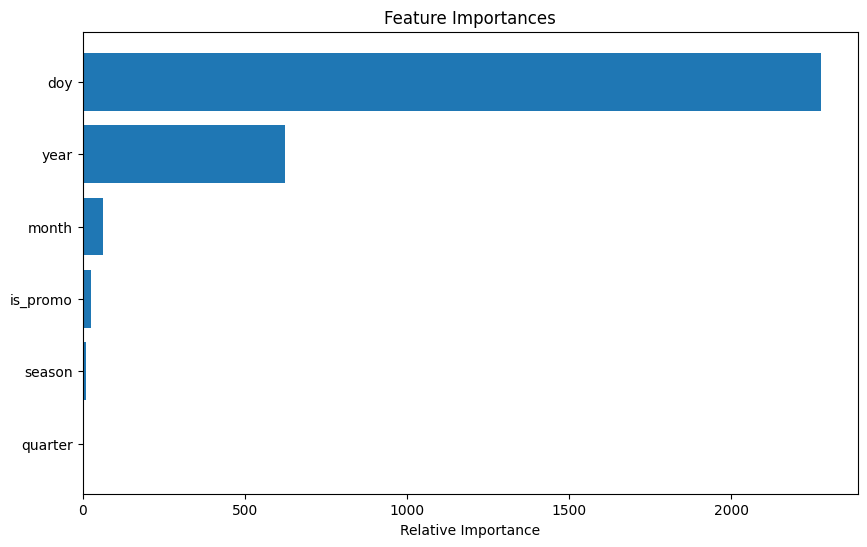

In [117]:
import numpy as np
# Show feature importance
import matplotlib.pyplot as plt
importances = model.feature_importances_
feature_names = X_rev_train.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


In [118]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_cogs_train['season'] = le.fit_transform(X_cogs_train['season'])
X_cogs_test['season'] = le.transform(X_cogs_test['season'])


In [119]:
mapping = {label: i for i, label in enumerate(le.classes_)}
mapping


{'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

In [120]:
model = LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_cogs_train, y_cogs_train)
y_cogs_pred = model.predict(X_cogs_test)
mae_cogs = mean_absolute_error(y_cogs_test, y_cogs_pred)
print(f"MAE for COGS: {mae_cogs:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 275
[LightGBM] [Info] Number of data points in the train set: 3066, number of used features: 6
[LightGBM] [Info] Start training from score 3689865.314977
MAE for COGS: 652784.75


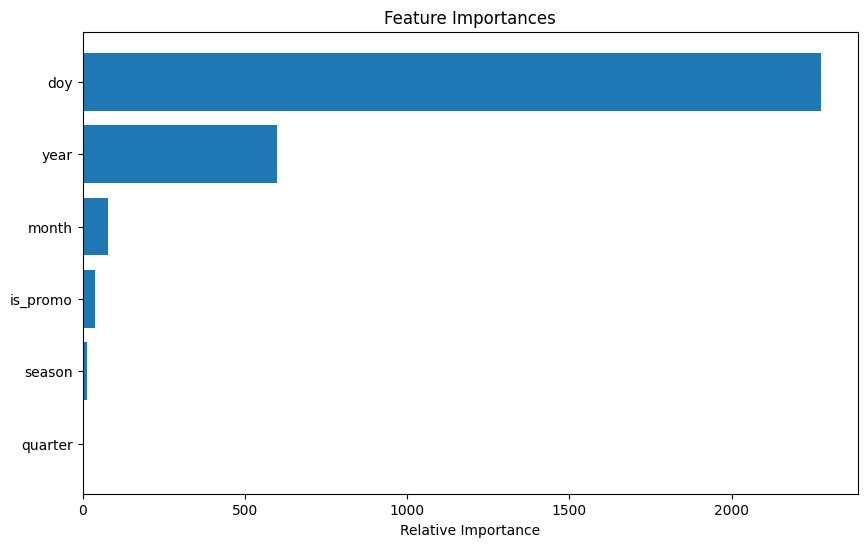

In [121]:
# Show feature importance
import matplotlib.pyplot as plt
importances = model.feature_importances_
feature_names = X_cogs_train.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()



In [122]:
# save model
import joblib
joblib.dump(model, "cogs_model.pkl")


['cogs_model.pkl']